# 06 · Evaluation & Selection

**Phase goal:** judge the winner on a held-out test set against the **business KPIs**, and make the final ship decision.

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import json
from car_pricing import config
m = json.loads(config.METRICS_PATH.read_text())
print(f"CV-best model : {m['cv_best_model']} (MAE {m['cv_best_mae_lakhs']} L)")
print(f"Shipped model : {m['winner']}")
print(f"  R^2          : {m['price_r2']}")
print(f"  MAE          : Rs {m['price_mae_lakhs']} Lakhs")
print(f"  RMSE         : Rs {m['price_rmse_lakhs']} Lakhs")
print(f"  Band accuracy: {m['band_accuracy']*100:.1f}%")
print(f"  KPI gate     : {'PASS' if m['kpi_gate']['all_pass'] else 'FAIL'}")

CV-best model : XGBoost (MAE 0.708 L)
Shipped model : LightGBM
  R^2          : 0.9568
  MAE          : Rs 0.664 Lakhs
  RMSE         : Rs 1.022 Lakhs
  Band accuracy: 85.8%
  KPI gate     : PASS


### The key selection decision: *ship the best model that also deploys*
**XGBoost** had the best cross-validated MAE, but the installed `xgboost 2.1` × `scikit-learn 1.6` combo can't serialise/serve it through a portable sklearn `Pipeline` (a library-version incompatibility). Since **LightGBM** is a statistical tie and serves cleanly with no version shim, `train.py` transparently ships LightGBM. *Operational robustness beats a 0.007-Lakh CV difference* — a real MLOps trade-off, not an accuracy one.

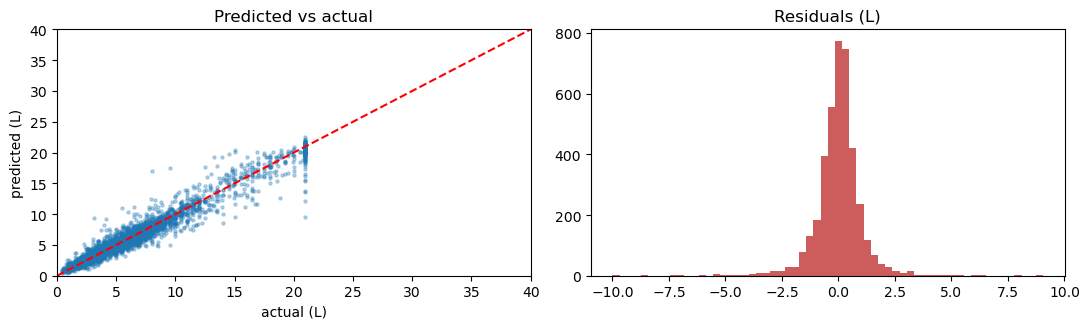

In [2]:
import pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from car_pricing import data, features
import joblib
df = data.clean(data.load_raw()); X, y = features.split_xy(df)
_, Xte, _, yte = train_test_split(X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE)
pipe = joblib.load(config.PIPELINE_PATH); pred = pipe.predict(Xte)
fig, ax = plt.subplots(1,2, figsize=(11,3.4))
ax[0].scatter(yte, pred, s=5, alpha=.3); ax[0].plot([0,40],[0,40],'r--')
ax[0].set(xlim=(0,40), ylim=(0,40), xlabel='actual (L)', ylabel='predicted (L)', title='Predicted vs actual')
ax[1].hist((pred-yte).clip(-10,10), bins=60, color='indianred'); ax[1].set(title='Residuals (L)')
plt.tight_layout(); plt.show()

In [3]:
# Band agreement (bands are DERIVED from the predicted price)
edges = features.band_edges(y)
tb = features.price_to_band(yte, edges); pb = features.price_to_band(pred, edges)
pd.crosstab(pd.Series(tb, name='actual'), pd.Series(pb, name='predicted'))

predicted,High,Low,Medium
actual,,,
High,1180,0,137
Low,2,1156,165
Medium,127,131,1066


### Error analysis
Most residuals are tight around zero; the widest misses are premium/rare models with thin data (a candidate for more data or per-segment models). The KPI gate passes, so the pipeline is cleared to ship (nb 07).